Load, pre - process and add a Noise to the Dataset:

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


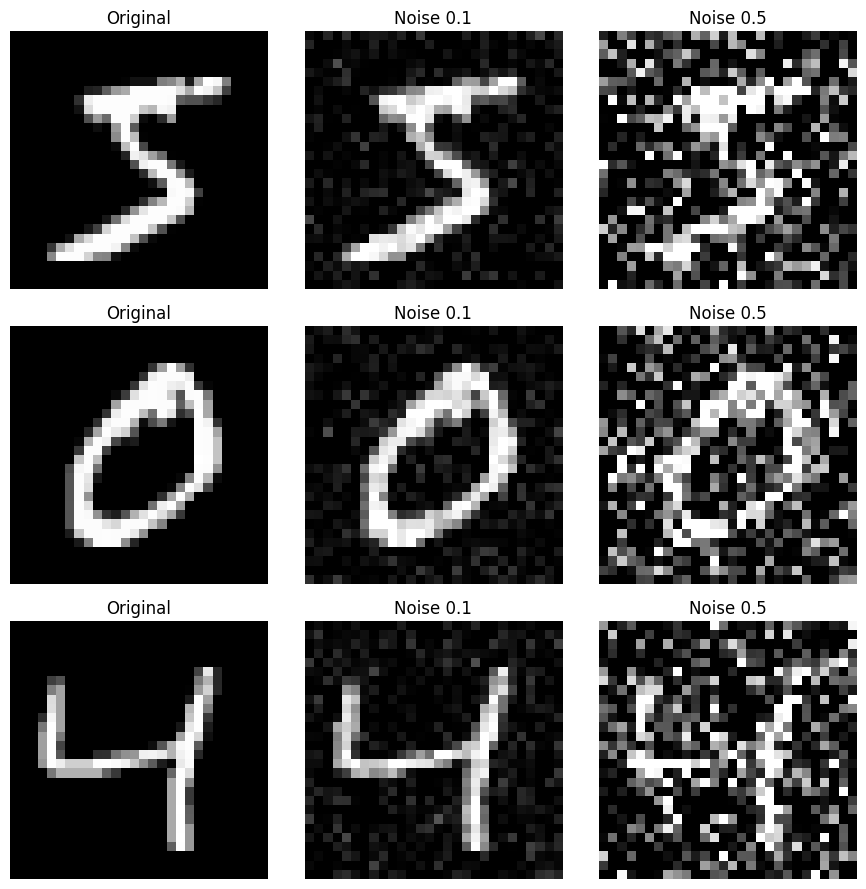

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()

# FIXED quotes here
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape to (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

# Visualize in a 3 x 3 grid
n = 3
plt.figure(figsize=(9, 9))

for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

Build the Convolutional Denoising Autoencoder Model:

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# -------------------------
# 🔹 Encoder
# -------------------------
def build_encoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)

    return input_img, encoded


# -------------------------
# 🔹 Decoder
# -------------------------
def build_decoder(encoded_input):

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)

    return decoded


# -------------------------
# 🔹 Full Autoencoder
# -------------------------
def build_autoencoder():
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")

    autoencoder.compile(
        optimizer=Adam(),
        loss='binary_crossentropy'
    )

    return autoencoder


# -------------------------
# 🔹 Build & Summary
# -------------------------
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Train the Autoencoder

In [4]:
# Build the autoencoder
autoencoder = build_autoencoder()

# Train with noisy input and clean target
history = autoencoder.fit(
    x_train_noisy_high,  # input (noisy images)
    x_train,             # target (clean images)
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 413ms/step - loss: 0.1491 - val_loss: 0.1121
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 409ms/step - loss: 0.1091 - val_loss: 0.1048
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 408ms/step - loss: 0.1041 - val_loss: 0.1017
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 408ms/step - loss: 0.1015 - val_loss: 0.0999
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 408ms/step - loss: 0.0998 - val_loss: 0.0982
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 409ms/step - loss: 0.0985 - val_loss: 0.0973
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 427ms/step - loss: 0.0976 - val_loss: 0.0967
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 219s 464ms/step - loss: 0.0969 - val_loss: 0.0960
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 409ms/step - loss: 0.0962 - val_loss: 0.0953
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 406ms/step - loss: 0.0957 - val_loss: 0.0949


Plot Training vs Validation Loss

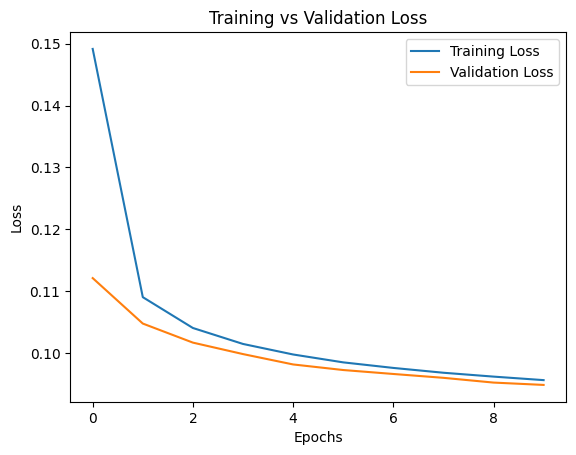

In [5]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

Evaluate the Autoencoder:

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step


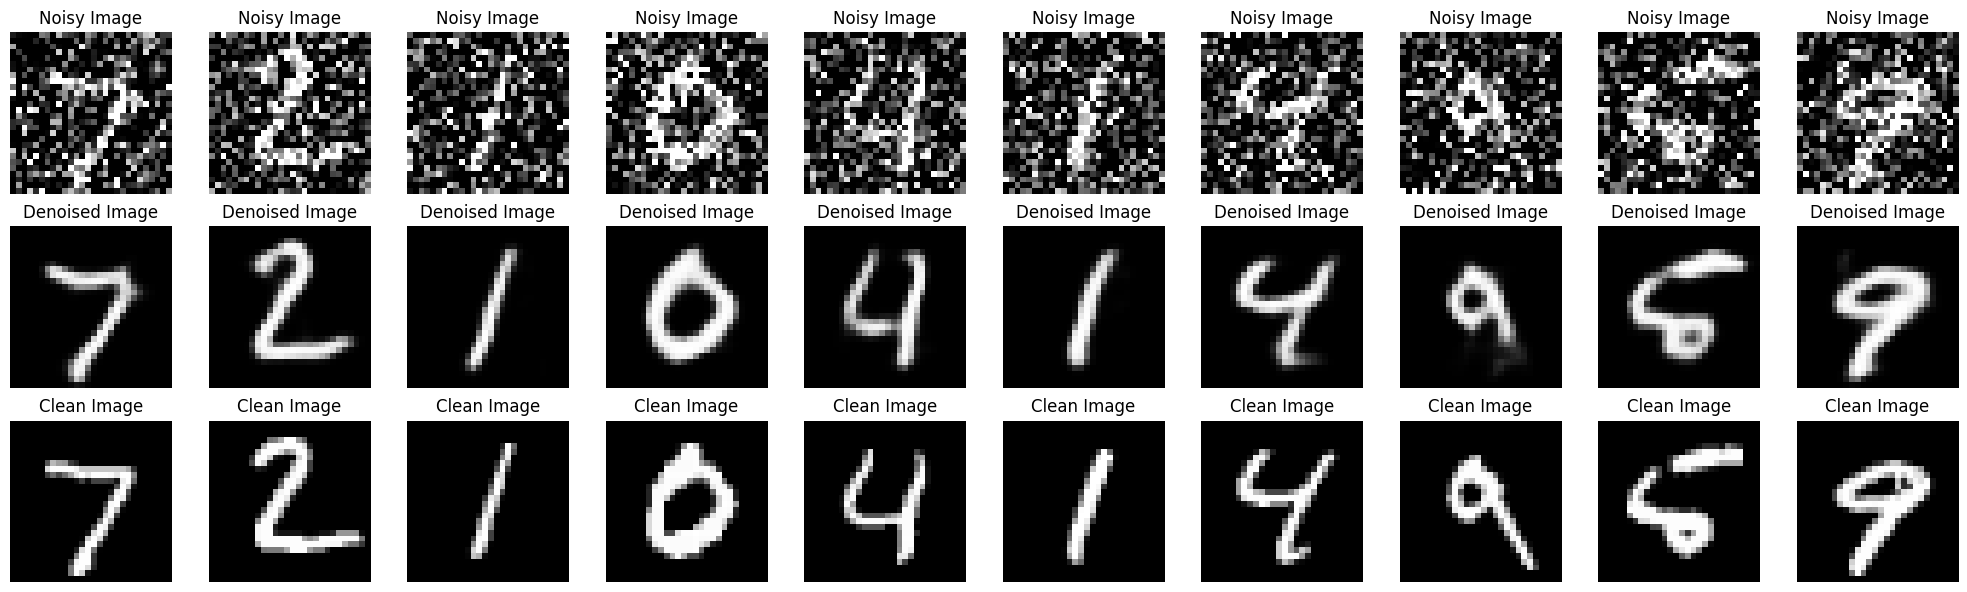

In [6]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Display results
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

Exercise

Dataset Preparation (Devnagari)

In [1]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# Path to dataset
data_dir = "/content/drive/MyDrive/AI/Data/DevanagariHandwrittenDigitDataset/Train"

images = []
count = 0
limit = 5000   # 🔥 use small subset first (change later to None for full dataset)

# Load images
for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):

            # 🔥 stop early for testing
            if limit and count >= limit:
                break

            img_path = os.path.join(folder_path, file)

            # ✅ skip non-image files / folders
            if os.path.isfile(img_path) and file.endswith(('.png', '.jpg', '.jpeg')):
                try:
                    img = Image.open(img_path).convert('L')
                    img = img.resize((28, 28))

                    img = np.array(img) / 255.0
                    images.append(img)

                    count += 1

                    # 🔥 progress print
                    if count % 1000 == 0:
                        print(f"{count} images loaded...")

                except Exception as e:
                    print("Skipping:", img_path)

        # 🔥 break outer loop too if limit reached
        if limit and count >= limit:
            break


# Convert to numpy
images = np.array(images)

# Add channel dimension
images = images.reshape(-1, 28, 28, 1)

# Train-test split
x_train, x_test = train_test_split(images, test_size=0.2, random_state=42)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

1000 images loaded...
2000 images loaded...
3000 images loaded...
4000 images loaded...
5000 images loaded...
Train shape: (4000, 28, 28, 1)
Test shape: (1000, 28, 28, 1)


Add Noise

In [2]:
noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

Build Deep Autoencoder (≥ 4 layers)

In [3]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

input_img = Input(shape=(28, 28, 1))

# 🔽 Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# 🔼 Decoder
x = Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer=Adam(),
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Train Model

Plot Loss

In [7]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - loss: 0.5203 - val_loss: 0.3320
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2687 - val_loss: 0.2404
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2197 - val_loss: 0.2091
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2028 - val_loss: 0.1989
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1959 - val_loss: 0.1940
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1920 - val_loss: 0.1908
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1889 - val_loss: 0.1884
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1868 - val_loss: 0.1866
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1853 - val_loss: 0.1851
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1841 - val_loss: 0.1838
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1827 - val_loss: 0.1833
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1819 - va

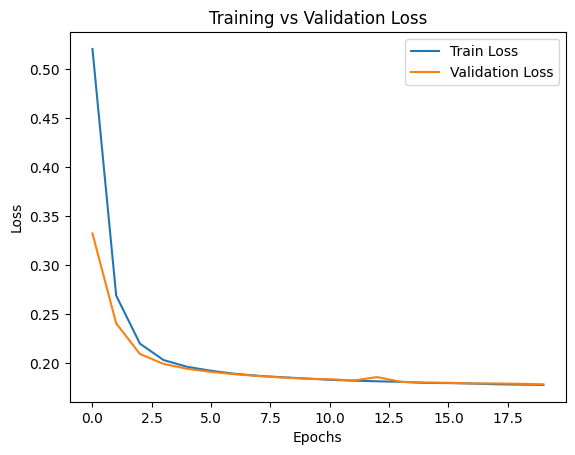

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Evaluate & Visualize

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


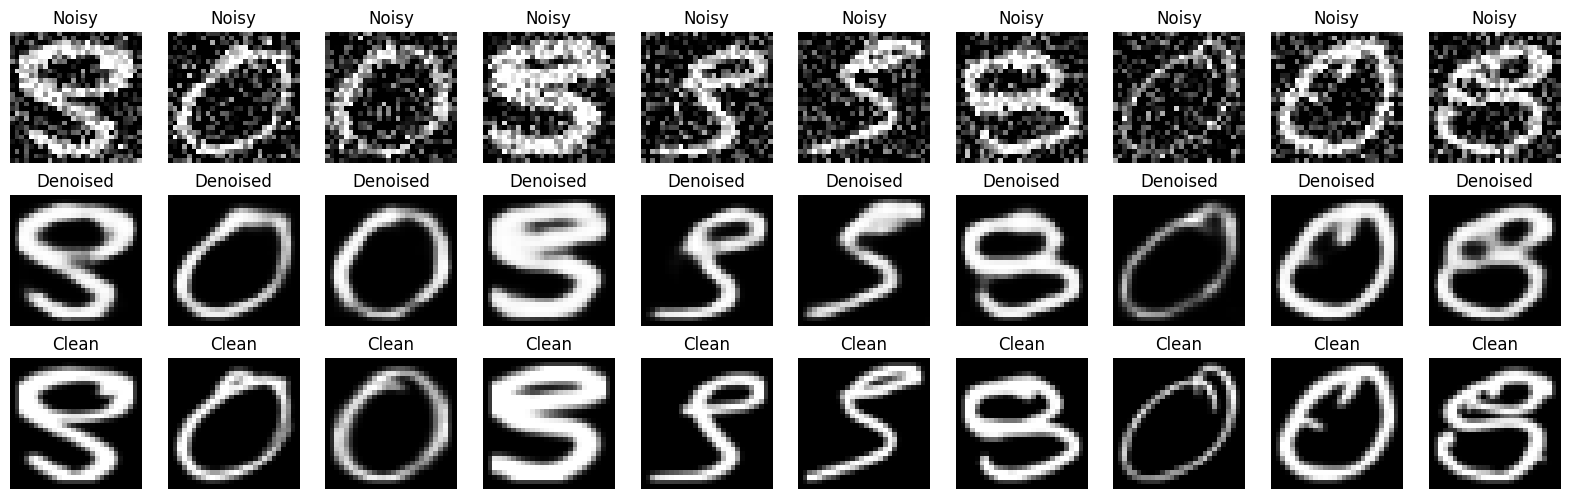

In [9]:
denoised_images = autoencoder.predict(x_test_noisy)

def plot_images(noisy, denoised, clean, n=10):
    plt.figure(figsize=(20,6))

    for i in range(n):
        # Noisy
        plt.subplot(3, n, i+1)
        plt.imshow(noisy[i].reshape(28,28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # Denoised
        plt.subplot(3, n, i+1+n)
        plt.imshow(denoised[i].reshape(28,28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        # Clean
        plt.subplot(3, n, i+1+2*n)
        plt.imshow(clean[i].reshape(28,28), cmap='gray')
        plt.title("Clean")
        plt.axis('off')

    plt.show()

plot_images(x_test_noisy, denoised_images, x_test)

Experiment: Different Noise Levels

Low noise

In [10]:
noise_factor = 0.1

x_train_noisy = x_train + noise_factor * np.random.normal(0, 1, x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(0, 1, x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

High noise

In [11]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(0, 1, x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(0, 1, x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

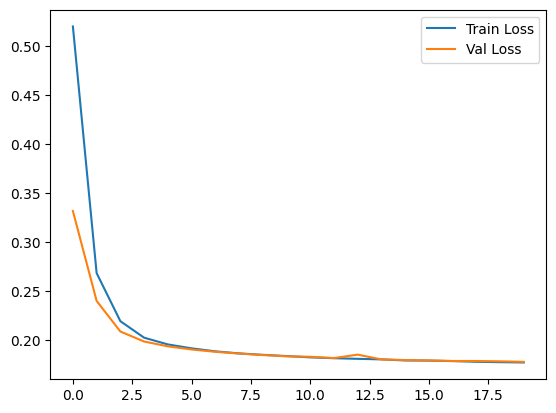

In [12]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()